# **Week 3 : Spatial Embeddings and Graph Construction**

In [1]:
import pandas as pd
import numpy as np

from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("week1_AB_NYC_2019.zip")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,No Review,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


**Build KNN Model**

In [4]:
coordinates = df[["latitude","longitude"]]

knn = NearestNeighbors(n_neighbors=6,algorithm="ball_tree")

knn.fit(coordinates)

distances, indices = knn.kneighbors(coordinates)

# **Create Spatial Features**
Average neighbhour price

In [5]:
neighbor_prices = []

for i in range(len(df)):

    neighbors = indices[i][1:]

    avg_price = df.iloc[neighbors]["price"].mean()

    neighbor_prices.append(avg_price)

df["avg_neighbor_price"] = neighbor_prices


Average neighbhour reviews

In [6]:
neighbor_reviews = []

for i in range(len(df)):

    neighbors = indices[i][1:]

    avg_reviews = df.iloc[neighbors]["number_of_reviews"].mean()

    neighbor_reviews.append(avg_reviews)

df["avg_neighbor_reviews"] = neighbor_reviews

Average neighbhour availability

In [7]:
neighbor_availability = []

for i in range(len(df)):

    neighbors = indices[i][1:]

    avg_availability = df.iloc[neighbors]["availability_365"].mean()

    neighbor_availability.append(avg_availability)

df["avg_neighbor_availability"] = neighbor_availability

In [8]:
neighbor_nights = []

for i in range(len(df)):

    neighbors = indices[i][1:]

    avg_nights = df.iloc[neighbors]["minimum_nights"].mean()

    neighbor_nights.append(avg_nights)

df["avg_neighbor_minimum_nights"] = neighbor_nights

In [9]:
df["neighbor_density"] = 5

In [10]:
df[[
    "avg_neighbor_price",
    "avg_neighbor_reviews",
    "avg_neighbor_availability",
    "avg_neighbor_minimum_nights"
]].head()

,avg_neighbor_price,avg_neighbor_reviews,avg_neighbor_availability,avg_neighbor_minimum_nights
0,151.4,43.8,131.0,10.0
1,190.8,35.6,166.6,2.6
2,183.0,20.2,103.6,12.6
3,124.8,13.6,59.6,3.8
4,160.0,6.0,203.6,4.2


In [11]:
features = ["latitude","longitude","minimum_nights","number_of_reviews","reviews_per_month","availability_365","avg_neighbor_price","avg_neighbor_reviews","avg_neighbor_availability","avg_neighbor_minimum_nights"]

X = df[features]

y = df["price"]

# **Train-Test Split**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [13]:
model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [14]:
prediction = model.predict(X_test)

# **Evaluation**

In [17]:
rmse = np.sqrt(mean_squared_error(y_test,prediction))

print("RMSE =" ,rmse)

RMSE = 56.545914350088104


In [18]:
mape = mean_absolute_percentage_error(y_test,prediction)

print("MAPE =",mape)

MAPE = 137642997972992.0


# **Feature Importance**

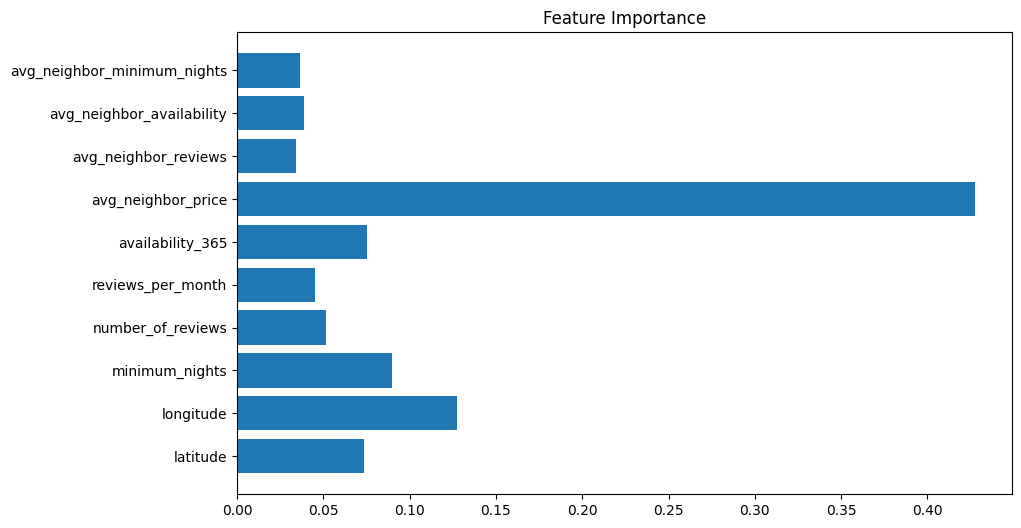

In [22]:
importance = model.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(features,importance)
plt.title("Feature Importance")
plt.show()

In [23]:
df.to_csv("week3_AB_NYC_2019.zip",index=False)

print("Week 3 Completed Successfully")

Week 3 Completed Successfully
